In [1]:
# Environment
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mac/Studying/OTTO/scenario_generator


In [2]:
# Build the full dataset
from src.dataset_builder import DatasetBuilder

builder = DatasetBuilder(config_dir="../config")
dataset = builder.build(
    scenario_paths=[
        "../config/scenarios/city_drive.yaml",
        "../config/scenarios/highway_cruise.yaml",
    ],
    output_dir="../data",
)

print(f"\nDataset built at: {dataset.output_dir}")
print(f"Manifest:  {dataset.manifest_path}")
print(f"Metadata:  {dataset.metadata_path}")

  ✓ sedan_a    / City Drive           →  10200 frames,  6000 signal rows
  ✓ suv_b      / Highway Cruise       →  15300 frames,  9000 signal rows

Dataset built at: ../data
Manifest:  ../data/manifest.csv
Metadata:  ../data/metadata.json


In [3]:
# Show the manifest
import pandas as pd

manifest = pd.read_csv(dataset.manifest_path)
print("Manifest:")
print(manifest.to_string(index=False))

Manifest:
vehicle_id  scenario_name  scenario_slug file_type                    relative_path  n_rows  size_bytes
   sedan_a     City Drive     city_drive    frames    sedan_a/city_drive.frames.csv   10200      304143
   sedan_a     City Drive     city_drive   signals   sedan_a/city_drive.signals.csv    6000      623586
     suv_b Highway Cruise highway_cruise    frames  suv_b/highway_cruise.frames.csv   15300      457143
     suv_b Highway Cruise highway_cruise   signals suv_b/highway_cruise.signals.csv    9000     1037309


In [4]:
# Show metadata summary
import json

with open(dataset.metadata_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

print(f"Generated at: {meta['generated_at']}")
print(f"Vehicles: {meta['vehicles']}")
print(f"Scenarios: {meta['n_scenarios']}")
print(f"Files: {meta['n_files']}")
print(f"Total frames: {meta['total_frames']:,}")
print(f"Total signal rows: {meta['total_signal_rows']:,}")
print(f"Total size: {meta['total_size_mb']} MB")

Generated at: 2026-09-24T15:33:12.254670+00:00
Vehicles: ['sedan_a', 'suv_b']
Scenarios: 2
Files: 4
Total frames: 25,500
Total signal rows: 15,000
Total size: 2.31 MB


In [6]:
# Directory tree
from pathlib import Path

data_dir = Path("../data")
print("Generated dataset structure:\n")
for path in sorted(data_dir.rglob("*")):
    if path.is_file():
        rel = path.relative_to(data_dir)
        size_kb = path.stat().st_size / 1024
        indent = "  " * (len(rel.parts) - 1)
        print(f"{indent}{rel.name:40s}  {size_kb:>8.1f} KB")

Generated dataset structure:

manifest.csv                                   0.4 KB
metadata.json                                  0.7 KB
  city_drive.frames.csv                        297.0 KB
  city_drive.signals.csv                       609.0 KB
  highway_cruise.frames.csv                    446.4 KB
  highway_cruise.signals.csv                  1013.0 KB


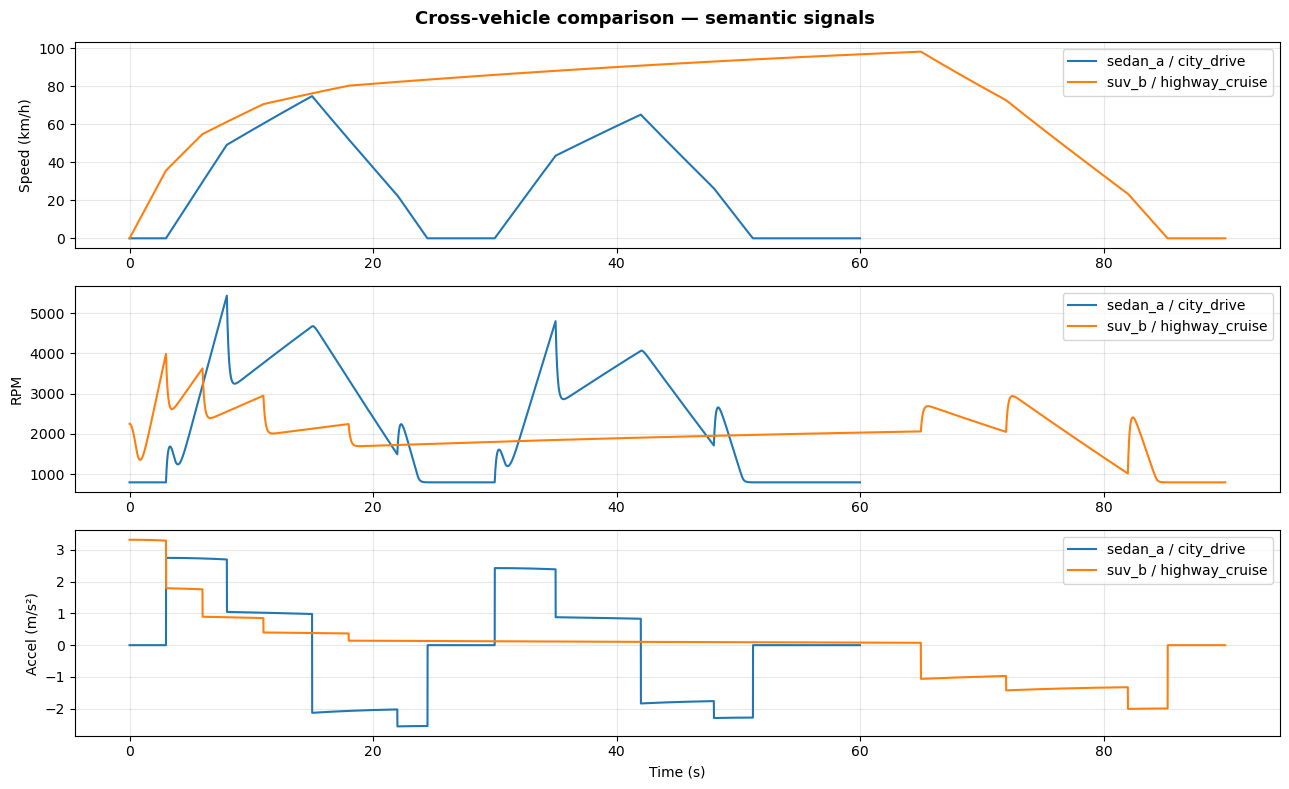

In [9]:
# Cell 5 — Cross-vehicle comparison: same scenario name, different vehicles
import pandas as pd
import matplotlib.pyplot as plt

# We only have city_drive for sedan_a and highway_cruise for suv_b
# (the scenario YAML declares vehicle_id, and we don't override it)
sedan_signals = pd.read_csv("../data/sedan_a/city_drive.signals.csv")
suv_signals = pd.read_csv("../data/suv_b/highway_cruise.signals.csv")

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=False)

axes[0].plot(sedan_signals["time_s"], sedan_signals["vehicle_speed"],
             label="sedan_a / city_drive", color="tab:blue")
axes[0].plot(suv_signals["time_s"], suv_signals["vehicle_speed"],
             label="suv_b / highway_cruise", color="tab:orange")
axes[0].set_ylabel("Speed (km/h)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sedan_signals["time_s"], sedan_signals["engine_rpm"],
             label="sedan_a / city_drive", color="tab:blue")
axes[1].plot(suv_signals["time_s"], suv_signals["engine_rpm"],
             label="suv_b / highway_cruise", color="tab:orange")
axes[1].set_ylabel("RPM")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(sedan_signals["time_s"], sedan_signals["longitudinal_acceleration"],
             label="sedan_a / city_drive", color="tab:blue")
axes[2].plot(suv_signals["time_s"], suv_signals["longitudinal_acceleration"],
             label="suv_b / highway_cruise", color="tab:orange")
axes[2].set_ylabel("Accel (m/s²)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Cross-vehicle comparison — semantic signals",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

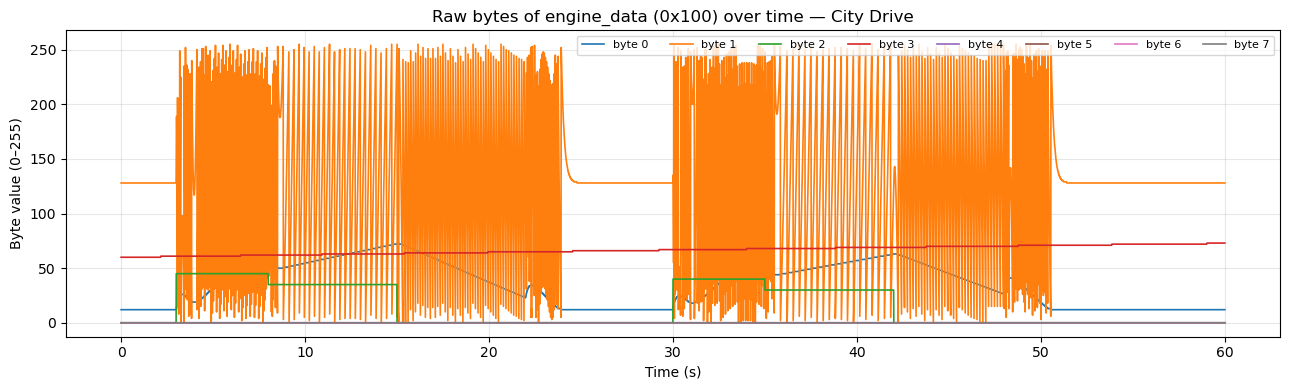

In [12]:
# Byte-level view of engine_data (0x100) — City Drive
import numpy as np
import matplotlib.pyplot as plt

frames = pd.read_csv("../data/sedan_a/city_drive.frames.csv")
engine = frames[frames["can_id"] == "0x100"].copy()
engine["t_s"] = engine["timestamp_ms"] / 1000
byte_matrix = np.array([list(bytes.fromhex(p)) for p in engine["payload_hex"]])

fig, ax = plt.subplots(figsize=(13, 4))
for b in range(8):
    ax.plot(engine["t_s"], byte_matrix[:, b], label=f"byte {b}", linewidth=1.2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Byte value (0–255)")
ax.set_title("Raw bytes of engine_data (0x100) over time — City Drive")
ax.legend(fontsize=8, ncol=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

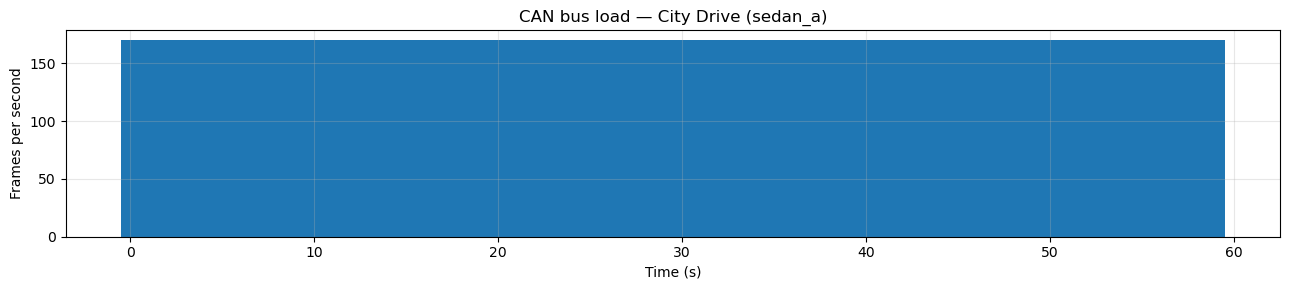

In [13]:
# Frames per second — all CAN IDs, City Drive
frames["second"] = frames["timestamp_ms"] // 1000
rate = frames.groupby("second").size()

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(rate.index, rate.values, width=1.0)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frames per second")
ax.set_title("CAN bus load — City Drive (sedan_a)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

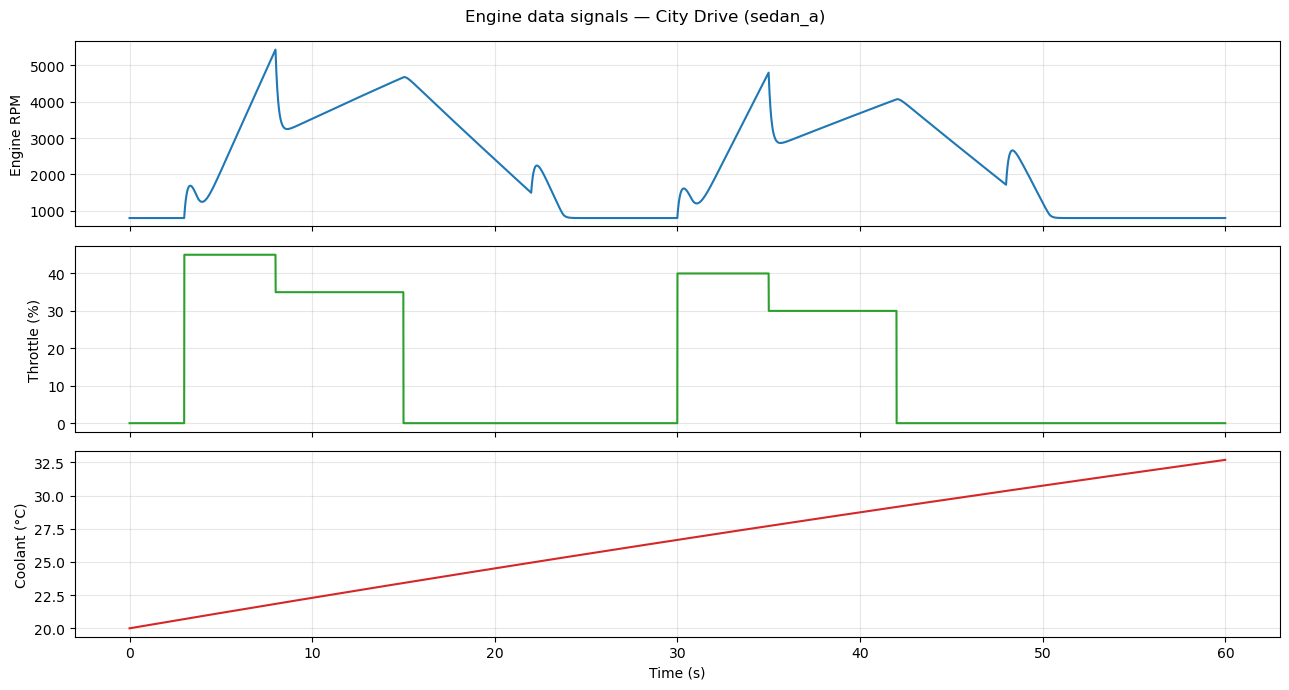

In [14]:
signals = pd.read_csv("../data/sedan_a/city_drive.signals.csv")

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

axes[0].plot(signals["time_s"], signals["engine_rpm"], color="tab:blue")
axes[0].set_ylabel("Engine RPM")
axes[0].grid(alpha=0.3)

axes[1].plot(signals["time_s"], signals["throttle_position"], color="tab:green")
axes[1].set_ylabel("Throttle (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(signals["time_s"], signals["coolant_temperature"], color="tab:red")
axes[2].set_ylabel("Coolant (°C)")
axes[2].set_xlabel("Time (s)")
axes[2].grid(alpha=0.3)

fig.suptitle("Engine data signals — City Drive (sedan_a)")
plt.tight_layout()
plt.show()